# HEST coverage95 formal benchmark table

This notebook combines the formal HistoOmniST benchmark-format evaluation with the statistical/SF-only baselines. It uses the same high-confidence HEST human Visium test split, the same 16,942 coverage95 canonical gene symbols, and the same gene-wise Pearson reporting convention.

## Inputs

- HistoOmniST benchmark output: `results/hest1k_human_visium_expression/benchmark_results/histoomnist_coverage95/`
- Statistical baselines: `results/hest1k_human_visium_expression/statistical_baselines/`
- Coverage95 diagnostics: `results/hest1k_human_visium_expression/coverage95_diagnostics/`

The benchmark-format HistoOmniST evaluation is streaming. It writes metrics in the same directory structure expected for external baselines, without writing multi-GB full prediction matrices.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

CWD = Path.cwd()
ROOT = CWD if (CWD / "configs").exists() else CWD.parent
BASE = ROOT / "results" / "hest1k_human_visium_expression"
HISTO = BASE / "benchmark_results" / "histoomnist_coverage95"
STAT = BASE / "statistical_baselines"
DIAG = BASE / "coverage95_diagnostics"

required = [
    HISTO / "summary.csv",
    HISTO / "run_summary.json",
    STAT / "summary.csv",
    STAT / "run_summary.json",
    DIAG / "run_summary.json",
]
missing = [str(path.relative_to(ROOT)) for path in required if not path.exists()]
assert not missing, missing

histo = pd.read_csv(HISTO / "summary.csv")
stat = pd.read_csv(STAT / "summary.csv")
histo_run = json.loads((HISTO / "run_summary.json").read_text(encoding="utf-8"))
stat_run = json.loads((STAT / "run_summary.json").read_text(encoding="utf-8"))
diag_run = json.loads((DIAG / "run_summary.json").read_text(encoding="utf-8"))

combined = pd.concat([stat, histo], ignore_index=True)
combined["family"] = combined["method"].map(lambda x: "HistoOmniST" if x.startswith("histoomnist") else "SF-only/statistical")
combined = combined[["family", "method", "prediction_kind", "mean_gene_pearson", "median_gene_pearson", "valid_genes"]]

display(Markdown(f"Test slides: **{histo_run['n_slides']}**; spots: **{histo_run['n_spots']:,}**; genes: **{histo_run['n_genes']:,}**"))
display(combined.round(4))

Test slides: **48**; spots: **121,421**; genes: **16,942**

,family,method,prediction_kind,mean_gene_pearson,median_gene_pearson,valid_genes
0,SF-only/statistical,global_mean_rate,rate,0.0000,0.0000,2962
1,SF-only/statistical,global_sf_only_count_pred_sf,count,0.1413,0.1443,16942
2,SF-only/statistical,global_sf_only_count_oracle_sf,count,0.2029,0.2110,16942
3,SF-only/statistical,organ_sf_only_count_pred_sf,count,0.2494,0.2628,16942
4,SF-only/statistical,organ_sf_only_count_oracle_sf,count,0.3136,0.3323,16942
5,HistoOmniST,histoomnist_rate,rate,0.1583,0.1268,16942
6,HistoOmniST,histoomnist_count_no_sf,count,0.3278,0.3454,16942
7,HistoOmniST,histoomnist_count_pred_sf,count,0.3529,0.3780,16942
8,HistoOmniST,histoomnist_count_oracle_sf,count,0.3976,0.4298,16942


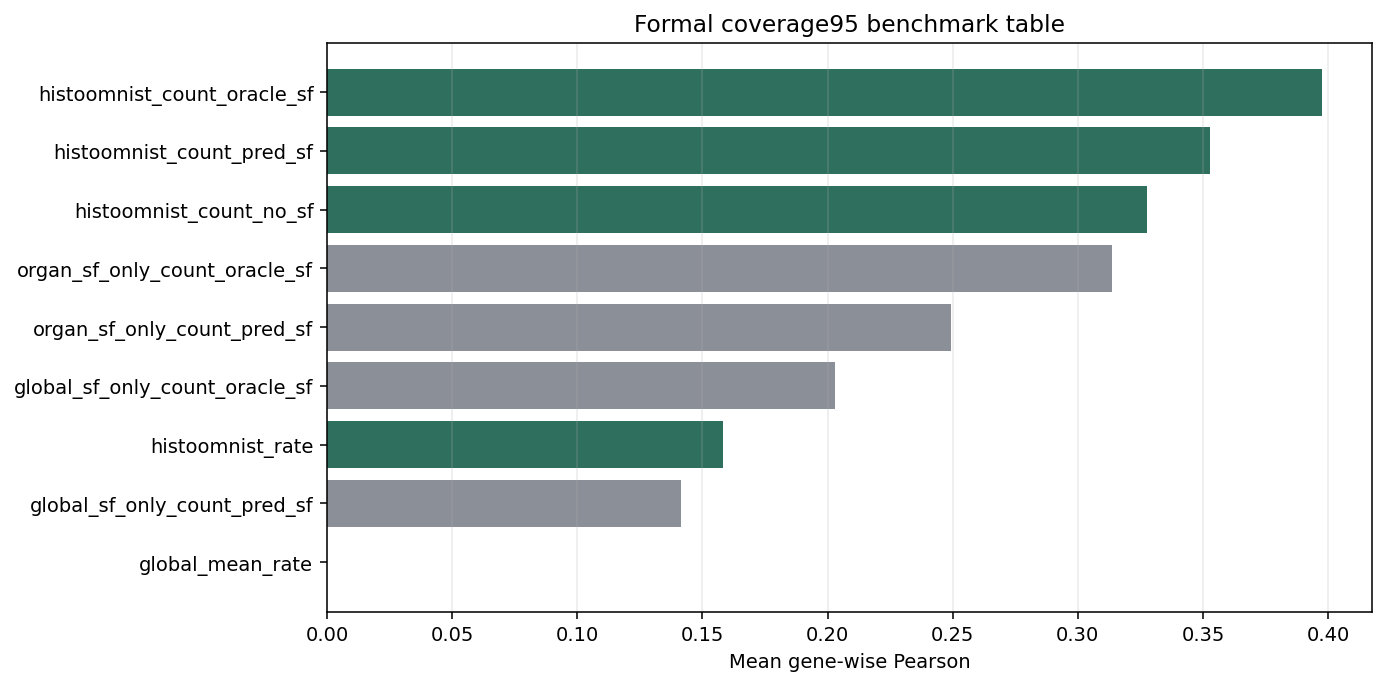

In [2]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=140)
plot_df = combined.sort_values("mean_gene_pearson", ascending=True).copy()
colors = plot_df["family"].map({"HistoOmniST": "#2f6f5e", "SF-only/statistical": "#8b8f97"})
ax.barh(plot_df["method"], plot_df["mean_gene_pearson"], color=colors)
ax.set_xlabel("Mean gene-wise Pearson")
ax.set_title("Formal coverage95 benchmark table")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()

## Consistency check

The benchmark-format HistoOmniST summary should reproduce the coverage95 diagnostics notebook values. This check guards against metric drift between the diagnostics path and the formal benchmark path.

In [3]:
checks = []
for metric, diag_values in diag_run["expression_overall"].items():
    method = {
        "rate": "histoomnist_rate",
        "count_no_sf": "histoomnist_count_no_sf",
        "count_pred_sf": "histoomnist_count_pred_sf",
        "count_oracle_sf": "histoomnist_count_oracle_sf",
    }[metric]
    row = histo[histo["method"].eq(method)].iloc[0]
    checks.append({
        "metric": metric,
        "benchmark_method": method,
        "diagnostics_mean": diag_values["mean_gene_pearson"],
        "benchmark_mean": row["mean_gene_pearson"],
        "abs_delta": abs(diag_values["mean_gene_pearson"] - row["mean_gene_pearson"]),
    })
check_df = pd.DataFrame(checks)
display(check_df)
assert check_df["abs_delta"].max() < 1e-10

,metric,benchmark_method,diagnostics_mean,benchmark_mean,abs_delta
0,rate,histoomnist_rate,0.158303,0.158303,0.000000e+00
1,count_no_sf,histoomnist_count_no_sf,0.327788,0.327788,5.551115e-17
2,count_pred_sf,histoomnist_count_pred_sf,0.352898,0.352898,0.000000e+00
3,count_oracle_sf,histoomnist_count_oracle_sf,0.397610,0.397610,5.551115e-17


## Interpretation checkpoint

The full HistoOmniST count-scale result (`histoomnist_count_pred_sf`, mean gene-wise Pearson 0.353) is higher than the H&E-derived SF-only baselines (`global_sf_only_count_pred_sf`, 0.141; `organ_sf_only_count_pred_sf`, 0.249). The organ-aware oracle SF-only baseline reaches 0.314, which shows that size factor and organ composition matter, but they do not explain the full expression-model signal.

This table is now ready to receive external method rows once HisToGene, HiST, iStar, mclSTExp, sCellST, and THItoGene export predictions under the same harness.